In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
import yaml
import os

# Set up pandas to not use scientific notation for numeric cells
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [22]:
run_id = '1775447283'

In [23]:
config_path = os.path.join(pu.get_data_path(), 'runs', run_id, 'runner_config.yml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
schema_name = config['basic_config']['schema_name']
workload_config = config['workload_config']
schema_name, workload_config

('ext_tpcds1000',
 {'workload_name': 'redbench_provisioned_157_0',
  'abs_start_time_start': '2024-05-27T00:00:00',
  'abs_start_time_end': '2024-05-28T00:00:00',
  'rescale_factor': 0.16666667,
  'closed_loop': False})

In [24]:
structured_log_path = os.path.join(pu.get_data_path(), 'runs', run_id, 'structured_log.parquet')
structured_log_df = pd.read_parquet(structured_log_path)
structured_log_df.head()

,timestamp,source,event_type,query_id,query_text_id,cluster_name,candidate_rpu,capacity_pressure,checkpoint_time_s,closed_loop,...,pending_count,reason,routing_policy,routing_time_s,rpu,run_id,slo_threshold,window_headroom,window_size,workload_name
0,1775447283.583,WorkloadRunner,run_start,None,None,None,NaN,None,NaN,False,...,NaN,None,ModelPolicy,NaN,NaN,1775447283,NaN,NaN,NaN,redbench_provisioned_157_0
1,1775447313.614,ModelPolicy(iconq_model_id=1771539369),routing_score,204510,None,autoslo-wg-16rpu-1775447026-0,NaN,None,NaN,None,...,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,None
2,1775447313.617,WorkloadRunner,query_routed,204510,ext_tpcds1000#009#003,autoslo-wg-16rpu-1775447026-0,NaN,None,NaN,None,...,NaN,None,None,0.003,NaN,1775447283,NaN,NaN,NaN,None
3,1775447313.617,router,query_start,204510,ext_tpcds1000#009#003,autoslo-wg-16rpu-1775447026-0,NaN,None,NaN,None,...,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,None
4,1775447313.617,headroom_policy,headroom_check,None,None,None,NaN,False,NaN,None,...,0.000,None,None,NaN,NaN,None,NaN,0.843,1.000,None


In [25]:
reference_ts = structured_log_df[structured_log_df['event_type'] == 'run_start']['timestamp'].min() + 30
# If there are timestamps more than 30 s less than the reference, increment them by the reference timestamp
structured_log_df.loc[structured_log_df['timestamp'] < (reference_ts - 60), 'timestamp'] += reference_ts
print(f"Reference timestamp: {reference_ts} ({pd.to_datetime(reference_ts, unit='s')})")

Reference timestamp: 1775447313.583109 (2026-04-06 03:48:33.583108902)


In [26]:
start_log_df = structured_log_df[structured_log_df['event_type'].isin(['query_start', 'query_execution_start'])][['timestamp', 'event_type', 'query_id', 'cluster_name']].copy().reset_index(drop=True)
start_log_df = start_log_df.pivot_table(index=['query_id', 'cluster_name'], columns='event_type', values='timestamp', sort=False).reset_index()
start_log_df = start_log_df.rename(columns={'query_start': 'query_start_time', 'query_execution_start': 'query_execution_start_time'})
start_log_df.columns.name = None
start_log_df['query_id'] = start_log_df['query_id'].astype(int)
start_log_df['actual_rel_start_time_s'] = start_log_df['query_start_time'] - reference_ts
start_log_df['actual_rel_execution_start_time_s'] = start_log_df['query_execution_start_time'] - reference_ts
start_log_df['delay_in_execution_start_s'] = start_log_df['actual_rel_execution_start_time_s'] - start_log_df['actual_rel_start_time_s']
# start_log_df = start_log_df.merge(workload.df[['query_id', 'rel_start_time_s']], on='query_id', how='inner')
# start_log_df['delay_in_real_start_s'] = start_log_df['actual_rel_start_time_s'] - start_log_df['rel_start_time_s']
print(start_log_df.shape)
start_log_df.head()

(1392, 7)


,query_id,cluster_name,query_start_time,query_execution_start_time,actual_rel_start_time_s,actual_rel_execution_start_time_s,delay_in_execution_start_s
0,204510,autoslo-wg-16rpu-1775447026-0,1775447313.617,1775447313.618,0.034,0.035,0.001
1,217123,autoslo-wg-16rpu-1775447026-0,1775447327.989,1775447327.990,14.406,14.407,0.001
2,193438,autoslo-wg-16rpu-1775447026-0,1775447442.222,1775447442.223,128.639,128.640,0.001
3,215584,autoslo-wg-16rpu-1775447026-0,1775447458.816,1775447458.817,145.233,145.234,0.001
4,209512,autoslo-wg-16rpu-1775447026-0,1775447894.798,1775447894.799,581.215,581.216,0.001


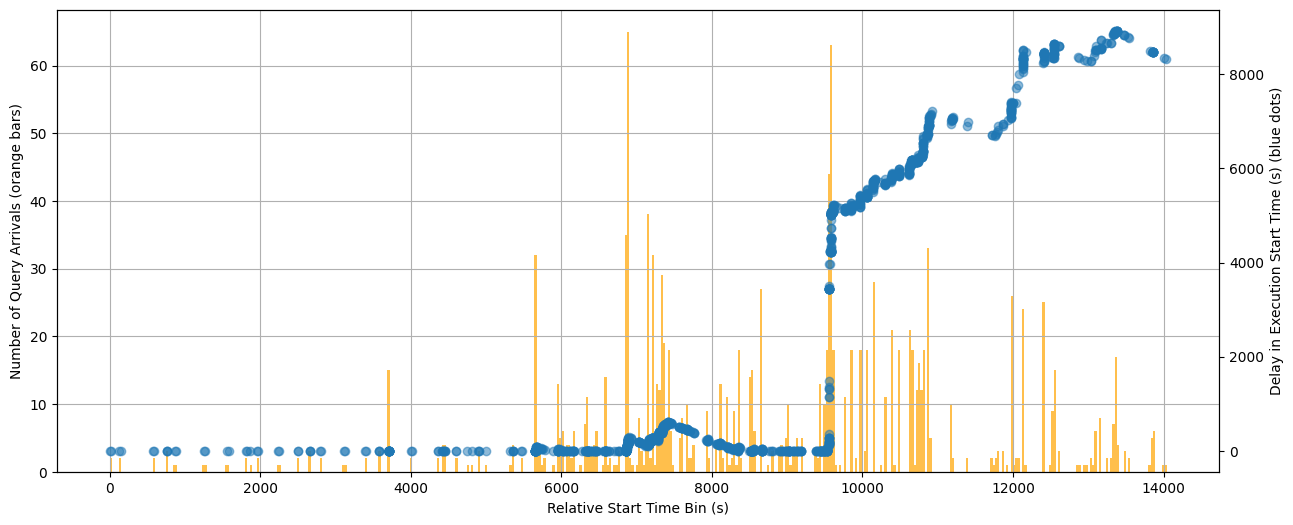

In [27]:
# Bin relative time in 30 second intervals and plot number of query arrivals per bin
start_log_df['rel_start_time_bin'] = (start_log_df['actual_rel_start_time_s'] // 30) * 30
arrival_counts = start_log_df.groupby('rel_start_time_bin').size().reset_index(name='arrival_count')

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(arrival_counts['rel_start_time_bin'], arrival_counts['arrival_count'], width=30, align='edge', alpha=0.7, color='orange')

ax2 = ax.twinx()
ax2.scatter(start_log_df['actual_rel_start_time_s'], start_log_df['delay_in_execution_start_s'], alpha=0.5, label='Delay')


ax.set_xlabel('Relative Start Time Bin (s)')
ax.set_ylabel('Number of Query Arrivals (orange bars)')
ax2.set_ylabel('Delay in Execution Start Time (s) (blue dots)')
ax.grid()
plt.show()